<div align="center">

# Laboratorio No. 2

## Representación vectorial y similitud de documentos

<br>

**Curso:** Natural Language Processing  
**Estudiante:** Jose Tánchez  
**Carné:** 20230005  

<br>

---

### Bolsa de Palabras, N-gramas, TF-IDF  
### y similitud coseno

#### Corpus de noticias en español

</div>

# Introducción

En este laboratorio se utilizará el corpus de noticias preparado y normalizado durante el Laboratorio No. 1.

A partir del texto normalizado de cada documento se construirán diferentes representaciones numéricas:

1. **Bolsa de Palabras (BoW).**
2. **N-gramas.**
3. **TF-IDF.**
4. **Vectores para calcular similitud coseno.**

Estas representaciones permitirán analizar el vocabulario, la dispersión de las matrices y la similitud entre las noticias del corpus.



In [4]:
from pathlib import Path
import pandas as pd
from IPython.display import display

# Buscar el corpus según la ubicación del notebook actual
rutas_posibles = [
    Path("corpus_normalizado.pkl"),
    Path("../Lab1/corpus_normalizado.pkl"),
    Path("Lab1/corpus_normalizado.pkl")
]

ruta_corpus = next(
    (ruta for ruta in rutas_posibles if ruta.exists()),
    None
)

if ruta_corpus is None:
    raise FileNotFoundError(
        "No se encontró 'corpus_normalizado.pkl'. "
        "Guárdalo primero desde el notebook de Lab 1."
    )

corpus = pd.read_pickle(ruta_corpus)

columnas_requeridas = [
    "url",
    "news",
    "Type",
    "tokens_lematizados",
    "News_normalizada"
]

columnas_faltantes = [
    columna
    for columna in columnas_requeridas
    if columna not in corpus.columns
]

if columnas_faltantes:
    raise ValueError(
        f"Faltan columnas necesarias: {columnas_faltantes}"
    )

print(f"Corpus cargado desde: {ruta_corpus.resolve()}")
print(f"Cantidad de documentos: {len(corpus):,}")
print(f"Cantidad de categorías: {corpus['Type'].nunique()}")
print("El corpus está listo para continuar.")

display(corpus[columnas_requeridas].head())

Corpus cargado desde: /Users/josetanchez/Desktop/NLP-Labs-JoseTanchez/Lab1/corpus_normalizado.pkl
Cantidad de documentos: 1,217
Cantidad de categorías: 7
El corpus está listo para continuar.


,url,news,Type,tokens_lematizados,News_normalizada
0,https://www.larepublica.co/redirect/post/3201905,Durante el foro La banca articulador empresari...,Otra,"[foro, banca, articulador, empresarial, desarr...",foro banca articulador empresarial desarrollo ...
1,https://www.larepublica.co/redirect/post/3210288,El regulador de valores de China dijo el domin...,Regulaciones,"[regulador, valor, chino, decir, domingo, busc...",regulador valor chino decir domingo buscar coo...
2,https://www.larepublica.co/redirect/post/3240676,En una industria históricamente masculina como...,Alianzas,"[industria, históricamente, masculino, aviació...",industria históricamente masculino aviación vi...
3,https://www.larepublica.co/redirect/post/3342889,Con el dato de marzo el IPC interanual encaden...,Macroeconomia,"[dato, marzo, ipc, interanual, encadenar, deci...",dato marzo ipc interanual encadenar decimoquin...
4,https://www.larepublica.co/redirect/post/3427208,Ayer en Cartagena se dio inicio a la versión n...,Otra,"[ayer, cartagena, dar, inicio, versión, número...",ayer cartagena dar inicio versión número 56 co...


# 1. Bolsa de Palabras (Bag of Words)

En esta sección se construirá una representación de **Bolsa de Palabras**, conocida como **Bag of Words (BoW)**, utilizando el texto normalizado de cada noticia.

Esta representación crea un vocabulario con las palabras diferentes del corpus y convierte cada documento en un vector de conteos. Cada posición del vector indica cuántas veces aparece una palabra determinada dentro del documento.

Para construir la matriz se utilizará `CountVectorizer` de scikit-learn y la columna `News_normalizada` obtenida durante el proceso de normalización.

In [6]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd
from IPython.display import display

# Crear el vectorizador utilizando los tokens ya normalizados
vectorizador_bow = CountVectorizer(
    tokenizer=str.split,
    preprocessor=None,
    token_pattern=None,
    lowercase=False
)

# Construir la matriz documentos × palabras
matriz_bow = vectorizador_bow.fit_transform(
    corpus["News_normalizada"].fillna("")
)

# Obtener el vocabulario aprendido
vocabulario_bow = vectorizador_bow.get_feature_names_out()

resumen_bow = pd.DataFrame({
    "Característica": [
        "Cantidad de documentos",
        "Tamaño del vocabulario",
        "Forma de la matriz"
    ],
    "Resultado": [
        matriz_bow.shape[0],
        matriz_bow.shape[1],
        str(matriz_bow.shape)
    ]
})

display(resumen_bow)

print(
    f"La matriz BoW contiene {matriz_bow.shape[0]:,} documentos "
    f"y {matriz_bow.shape[1]:,} términos."
)

,Característica,Resultado
0,Cantidad de documentos,1217
1,Tamaño del vocabulario,21944
2,Forma de la matriz,"(1217, 21944)"


La matriz BoW contiene 1,217 documentos y 21,944 términos.


## 1.1 Dimensiones de la matriz BoW

### Pregunta

¿Cuál es la forma de la matriz de Bolsa de Palabras obtenida?

### Respuesta

La matriz de Bolsa de Palabras tiene una forma de **1,217 documentos × 21944 palabras**, representada como:

\[
(1217,\ 21944)
\]

Cada fila corresponde a una noticia del corpus y cada columna representa una palabra diferente del vocabulario normalizado. El valor de cada celda indica cuántas veces aparece esa palabra en el documento correspondiente.

## 1.2 Información que se pierde y se gana

### Pregunta

¿Qué información se pierde al representar un documento como una bolsa de palabras y qué se gana a cambio?

### Respuesta

Al utilizar una Bolsa de Palabras se pierde el **orden original de las palabras**. También se ignoran la estructura gramatical, las relaciones entre palabras y parte del contexto de las oraciones.

Por ejemplo, las expresiones `banco aumenta inversión` e `inversión aumenta banco` tendrían una representación muy parecida, aunque el orden pueda cambiar su interpretación.

A cambio, se obtiene una representación numérica sencilla que permite identificar qué palabras aparecen en cada documento y cuántas veces lo hacen. Esta representación facilita el uso de algoritmos de aprendizaje automático y permite comparar o clasificar grandes cantidades de documentos de manera eficiente.

# 2. Vectores de conteo y dispersión

La matriz BoW contiene los conteos de las palabras presentes en cada noticia. Sin embargo, cada documento utiliza solamente una pequeña parte del vocabulario completo, por lo que la mayoría de las posiciones de la matriz tienen un valor de cero.

En esta sección se calculará la **dispersión** o **sparsity** de la matriz. Esta medida representa el porcentaje de celdas que contienen ceros, una dispersión elevada indica que la matriz contiene una gran cantidad de ceros y relativamente pocos valores distintos de cero.

In [7]:
# Calcular la cantidad total de celdas
total_celdas_bow = (
    matriz_bow.shape[0]
    * matriz_bow.shape[1]
)

# nnz almacena la cantidad de valores distintos de cero
celdas_no_cero_bow = matriz_bow.nnz
celdas_cero_bow = total_celdas_bow - celdas_no_cero_bow

dispersion_bow = (
    celdas_cero_bow
    / total_celdas_bow
    * 100
)

densidad_bow = 100 - dispersion_bow

resumen_dispersion_bow = pd.DataFrame({
    "Medida": [
        "Celdas totales",
        "Celdas con valor distinto de cero",
        "Celdas con cero",
        "Dispersión (%)",
        "Densidad (%)"
    ],
    "Resultado": [
        f"{total_celdas_bow:,}",
        f"{celdas_no_cero_bow:,}",
        f"{celdas_cero_bow:,}",
        f"{dispersion_bow:.4f}%",
        f"{densidad_bow:.4f}%"
    ]
})

display(resumen_dispersion_bow)

print(
    f"El {dispersion_bow:.4f}% de las celdas "
    "de la matriz BoW contiene ceros."
)

,Medida,Resultado
0,Celdas totales,"26,705,848"
1,Celdas con valor distinto de cero,"230,088"
2,Celdas con cero,"26,475,760"
3,Dispersión (%),99.1384%
4,Densidad (%),0.8616%


El 99.1384% de las celdas de la matriz BoW contiene ceros.


,Límite del vocabulario,Vocabulario obtenido,Valores distintos de cero,Dispersión (%)
0,100,100,36716,69.8307
1,500,500,98949,83.7389
2,1000,1000,134384,88.9578
3,5000,5000,200623,96.7030


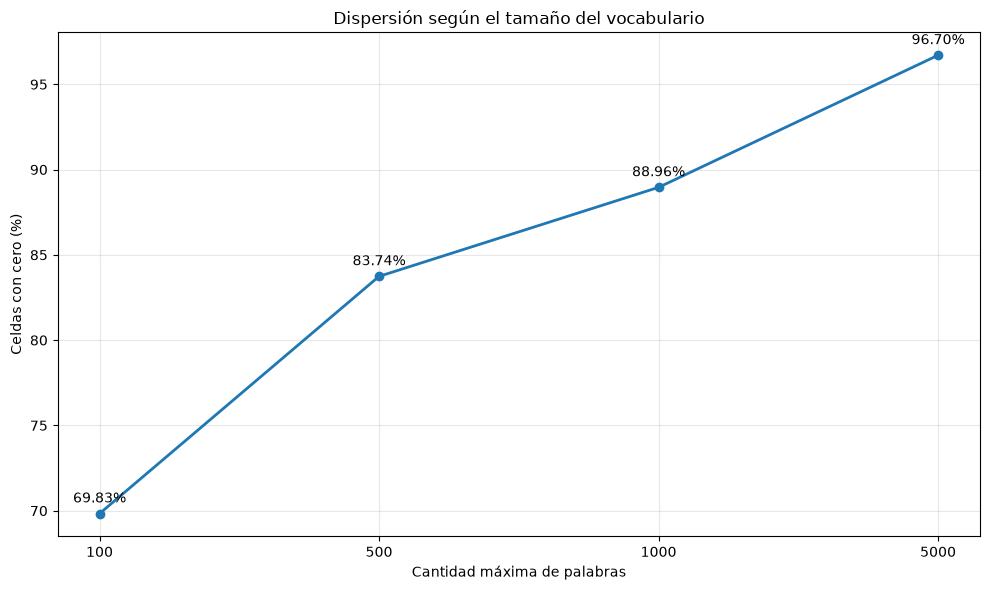

In [8]:
import matplotlib.pyplot as plt

limites_vocabulario = [100, 500, 1000, 5000]

resultados_dispersion = []
matrices_bow_limitadas = {}

for limite in limites_vocabulario:
    vectorizador_limitado = CountVectorizer(
        tokenizer=str.split,
        preprocessor=None,
        token_pattern=None,
        lowercase=False,
        max_features=limite
    )

    matriz_limitada = vectorizador_limitado.fit_transform(
        corpus["News_normalizada"].fillna("")
    )

    matrices_bow_limitadas[limite] = matriz_limitada

    total_celdas = (
        matriz_limitada.shape[0]
        * matriz_limitada.shape[1]
    )

    celdas_no_cero = matriz_limitada.nnz
    celdas_cero = total_celdas - celdas_no_cero

    porcentaje_dispersion = (
        celdas_cero
        / total_celdas
        * 100
    )

    resultados_dispersion.append({
        "Límite del vocabulario": limite,
        "Vocabulario obtenido": matriz_limitada.shape[1],
        "Valores distintos de cero": celdas_no_cero,
        "Dispersión (%)": porcentaje_dispersion
    })

resultados_dispersion_df = pd.DataFrame(
    resultados_dispersion
)

display(
    resultados_dispersion_df.style.format({
        "Dispersión (%)": "{:.4f}"
    })
)

# Graficar los resultados
posiciones = range(len(resultados_dispersion_df))

plt.figure(figsize=(10, 6))

plt.plot(
    posiciones,
    resultados_dispersion_df["Dispersión (%)"],
    marker="o",
    linewidth=2
)

plt.xticks(
    posiciones,
    resultados_dispersion_df["Límite del vocabulario"]
)

for posicion, dispersion in zip(
    posiciones,
    resultados_dispersion_df["Dispersión (%)"]
):
    plt.annotate(
        f"{dispersion:.2f}%",
        (posicion, dispersion),
        textcoords="offset points",
        xytext=(0, 8),
        ha="center"
    )

plt.title(
    "Dispersión según el tamaño del vocabulario"
)
plt.xlabel("Cantidad máxima de palabras")
plt.ylabel("Celdas con cero (%)")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 2.1 Dispersión de la matriz de conteos

### Pregunta

¿Qué porcentaje de las celdas de la matriz BoW contiene ceros?

### Respuesta

El resultado obtenido muestra que **más del 99 % de las celdas de la matriz contiene ceros**. Esto significa que cada noticia utiliza solamente una pequeña parte de las 21944 palabras que forman el vocabulario completo.

Por lo tanto, la matriz BoW es altamente dispersa: contiene pocos conteos distintos de cero en comparación con su cantidad total de posiciones.

## 2.2 Efecto del tamaño del vocabulario

### Pregunta

¿Por qué aumenta la dispersión cuando se amplía el vocabulario?

### Respuesta

El gráfico muestra que la dispersión aumenta al pasar de 100 a 500, 1,000 y 5,000 palabras.

Cuando se agregan términos al vocabulario, se crean nuevas columnas en la matriz. Muchas de estas palabras aparecen solamente en una cantidad pequeña de noticias, por lo que la mayoría de los documentos recibe un cero en esas nuevas columnas.

En una matriz densa, aumentar el vocabulario incrementaría considerablemente el costo de almacenamiento y de cómputo, porque también se almacenarían y procesarían todos esos ceros.

## 2.3 Matrices dispersas y formato CSR

### Pregunta

¿Qué es una matriz dispersa y por qué se utilizan estructuras especiales como CSR?

### Respuesta

Una **matriz dispersa** es una matriz en la que la mayoría de sus elementos tiene un valor de cero. Este comportamiento es común en el procesamiento de texto porque cada documento contiene únicamente una parte del vocabulario completo.

El formato **CSR**, cuyo nombre significa *Compressed Sparse Row*, almacena principalmente:

- Los valores distintos de cero.
- La columna donde aparece cada valor.
- La posición donde comienza cada fila.

De esta manera no es necesario guardar individualmente todos los ceros. Esto reduce el uso de memoria y permite que muchas operaciones matemáticas se realicen con mayor rapidez. Por esta razón, `CountVectorizer` devuelve una matriz dispersa en lugar de una matriz densa convencional.

# 3. N-gramas

La Bolsa de Palabras clásica representa cada palabra de manera individual y no conserva información sobre las palabras que aparecen juntas.

Los **n-gramas** permiten representar secuencias consecutivas de palabras:

- Un **unigrama** contiene una sola palabra.
- Un **bigrama** contiene dos palabras consecutivas.
- Un **trigrama** contiene tres palabras consecutivas.

En esta sección se utilizará `CountVectorizer` con el parámetro `ngram_range` para construir una representación de unigramas y otra de bigramas. Después se comparará el tamaño de sus vocabularios y se identificarán los 15 bigramas más frecuentes del corpus normalizado.

In [9]:
from sklearn.feature_extraction.text import CountVectorizer

textos_normalizados = corpus[
    "News_normalizada"
].fillna("")

# Representación formada únicamente por unigramas
vectorizador_unigramas = CountVectorizer(
    tokenizer=str.split,
    preprocessor=None,
    token_pattern=None,
    lowercase=False,
    ngram_range=(1, 1)
)

matriz_unigramas = vectorizador_unigramas.fit_transform(
    textos_normalizados
)

vocabulario_unigramas = (
    vectorizador_unigramas.get_feature_names_out()
)

# Representación formada únicamente por bigramas
vectorizador_bigramas = CountVectorizer(
    tokenizer=str.split,
    preprocessor=None,
    token_pattern=None,
    lowercase=False,
    ngram_range=(2, 2)
)

matriz_bigramas = vectorizador_bigramas.fit_transform(
    textos_normalizados
)

vocabulario_bigramas = (
    vectorizador_bigramas.get_feature_names_out()
)

resumen_ngramas = pd.DataFrame({
    "Representación": [
        "Unigramas",
        "Bigramas"
    ],
    "N-gram range": [
        "(1, 1)",
        "(2, 2)"
    ],
    "Cantidad de documentos": [
        matriz_unigramas.shape[0],
        matriz_bigramas.shape[0]
    ],
    "Tamaño del vocabulario": [
        matriz_unigramas.shape[1],
        matriz_bigramas.shape[1]
    ],
    "Forma de la matriz": [
        str(matriz_unigramas.shape),
        str(matriz_bigramas.shape)
    ]
})

display(resumen_ngramas)

,Representación,N-gram range,Cantidad de documentos,Tamaño del vocabulario,Forma de la matriz
0,Unigramas,"(1, 1)",1217,21944,"(1217, 21944)"
1,Bigramas,"(2, 2)",1217,225523,"(1217, 225523)"


In [10]:
import numpy as np

# Sumar los conteos de cada bigrama en todos los documentos
frecuencias_bigramas = np.asarray(
    matriz_bigramas.sum(axis=0)
).ravel()

# Obtener las posiciones de los 15 bigramas más frecuentes
indices_bigramas_frecuentes = np.argsort(
    -frecuencias_bigramas,
    kind="stable"
)[:15]

tabla_bigramas_frecuentes = pd.DataFrame({
    "Bigrama": vocabulario_bigramas[
        indices_bigramas_frecuentes
    ],
    "Frecuencia": frecuencias_bigramas[
        indices_bigramas_frecuentes
    ].astype(int)
})

tabla_bigramas_frecuentes.index = range(
    1,
    len(tabla_bigramas_frecuentes) + 1
)

tabla_bigramas_frecuentes.index.name = "Posición"

display(tabla_bigramas_frecuentes)

,Bigrama,Frecuencia
Posición,,
1,banco central,224
2,bbva research,212
3,poder ser,208
4,cada vez,197
5,tasa interés,192
6,000 millón,188
7,entidad financiero,179
8,cambio climático,166
9,bbva méxico,155


## 3.1 Tamaño de los vocabularios

### Pregunta

¿Cómo cambia el tamaño del vocabulario al pasar de unigramas a bigramas?

### Respuesta

La representación de unigramas contiene **21944 términos diferentes**. La tabla anterior muestra que el vocabulario de bigramas es considerablemente mayor.

Esto ocurre porque cada palabra constituye un posible unigrama, mientras que cada pareja diferente de palabras consecutivas constituye un nuevo bigrama. Por lo tanto, una misma palabra puede participar en muchas combinaciones distintas.

## 3.2 Bigramas más frecuentes

### Pregunta

¿Los 15 bigramas más frecuentes aportan información que los unigramas no capturan?

### Respuesta

Los bigramas mostrados en la tabla permiten identificar expresiones completas, nombres de organizaciones, lugares y conceptos que aparecen repetidamente en las noticias.

Esta información no se conserva completamente con unigramas. Al analizar las palabras por separado se conoce su frecuencia, pero no se sabe cuáles suelen aparecer juntas. Un bigrama puede representar un concepto más específico y conservar una pequeña parte del contexto local del documento.

Sin embargo, no todos los bigramas son igualmente informativos. Algunas combinaciones pueden aparecer con frecuencia debido a la forma de redacción de las noticias y no necesariamente porque representen un tema importante.

## 3.3 Ventajas y costos de los n-gramas

### Pregunta

¿Qué ventajas ofrecen los bigramas y trigramas frente a los unigramas y qué costo tienen?

### Respuesta

Los bigramas y trigramas conservan parte del orden de las palabras y permiten reconocer expresiones formadas por varios términos. Esto ayuda a diferenciar conceptos que una Bolsa de Palabras clásica trataría como palabras independientes.

Su principal costo es el crecimiento del vocabulario. La cantidad de combinaciones posibles es mucho mayor que la cantidad de palabras individuales. Como consecuencia, las matrices requieren más almacenamiento, presentan una dispersión más alta y pueden aumentar el tiempo necesario para entrenar o utilizar un modelo.

# 4. TF-IDF

La representación **TF-IDF** asigna un peso a cada palabra según su importancia dentro de un documento y dentro del corpus completo.

Este peso combina dos componentes:

- **TF (Term Frequency):** mide la frecuencia de una palabra dentro de un documento.
- **IDF (Inverse Document Frequency):** reduce el peso de las palabras que aparecen en muchos documentos y aumenta el de aquellas que aparecen en pocos.

De esta forma, una palabra recibe un puntaje alto cuando aparece varias veces dentro de una noticia, pero no es común en todo el corpus.

En esta sección se construirá la matriz TF-IDF y se seleccionarán tres noticias de categorías diferentes. Para cada una se compararán sus diez palabras con mayor TF-IDF con sus diez palabras más frecuentes según el conteo simple.

In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizador_tfidf = TfidfVectorizer(
    tokenizer=str.split,
    preprocessor=None,
    token_pattern=None,
    lowercase=False
)

matriz_tfidf = vectorizador_tfidf.fit_transform(
    corpus["News_normalizada"].fillna("")
)

vocabulario_tfidf = (
    vectorizador_tfidf.get_feature_names_out()
)

resumen_tfidf = pd.DataFrame({
    "Característica": [
        "Cantidad de documentos",
        "Tamaño del vocabulario",
        "Forma de la matriz",
        "Tipo de matriz"
    ],
    "Resultado": [
        matriz_tfidf.shape[0],
        matriz_tfidf.shape[1],
        str(matriz_tfidf.shape),
        type(matriz_tfidf).__name__
    ]
})

display(resumen_tfidf)

print(
    f"La matriz TF-IDF contiene "
    f"{matriz_tfidf.shape[0]:,} documentos y "
    f"{matriz_tfidf.shape[1]:,} términos."
)

,Característica,Resultado
0,Cantidad de documentos,1217
1,Tamaño del vocabulario,21944
2,Forma de la matriz,"(1217, 21944)"
3,Tipo de matriz,csr_matrix


La matriz TF-IDF contiene 1,217 documentos y 21,944 términos.


In [12]:
# Seleccionar las tres categorías con más documentos
categorias_seleccionadas = (
    corpus["Type"]
    .value_counts()
    .head(3)
    .index
    .tolist()
)

posiciones_documentos_seleccionados = []

for categoria in categorias_seleccionadas:
    mascara = (
        corpus["Type"].eq(categoria)
        & corpus["News_normalizada"]
        .fillna("")
        .str.strip()
        .ne("")
    )

    posiciones_validas = np.flatnonzero(
        mascara.to_numpy()
    )

    if len(posiciones_validas) == 0:
        raise ValueError(
            f"No hay documentos válidos en la categoría: {categoria}"
        )

    # Seleccionar el primer documento válido de la categoría
    posiciones_documentos_seleccionados.append(
        int(posiciones_validas[0])
    )

documentos_seleccionados = pd.DataFrame({
    "Posición en la matriz":
        posiciones_documentos_seleccionados,

    "Índice original": [
        corpus.index[posicion]
        for posicion in posiciones_documentos_seleccionados
    ],

    "Categoría": [
        corpus.iloc[posicion]["Type"]
        for posicion in posiciones_documentos_seleccionados
    ],

    "Vista previa del texto original": [
        corpus.iloc[posicion]["news"][:300] + "..."
        for posicion in posiciones_documentos_seleccionados
    ]
})

display(documentos_seleccionados)

,Posición en la matriz,Índice original,Categoría,Vista previa del texto original
0,3,3,Macroeconomia,Con el dato de marzo el IPC interanual encaden...
1,2,2,Alianzas,En una industria históricamente masculina como...
2,7,7,Innovacion,En el 'podcast' tenemos el placer de entrevist...


In [13]:
def obtener_palabras_tfidf(
    matriz,
    vocabulario,
    posicion_documento,
    cantidad=10
):
    """
    Obtiene las palabras con mayor puntaje TF-IDF
    de un documento.
    """

    fila_documento = matriz.getrow(
        posicion_documento
    )

    indices = fila_documento.indices
    puntajes = fila_documento.data

    orden = np.argsort(
        -puntajes,
        kind="stable"
    )[:cantidad]

    tabla = pd.DataFrame({
        "Palabra": vocabulario[indices[orden]],
        "Puntaje TF-IDF": puntajes[orden]
    })

    tabla.index = range(1, len(tabla) + 1)
    tabla.index.name = "Posición"

    return tabla


tablas_tfidf_documentos = {}

for numero, posicion_documento in enumerate(
    posiciones_documentos_seleccionados,
    start=1
):
    categoria = corpus.iloc[
        posicion_documento
    ]["Type"]

    tabla_tfidf = obtener_palabras_tfidf(
        matriz_tfidf,
        vocabulario_tfidf,
        posicion_documento,
        cantidad=10
    )

    tablas_tfidf_documentos[
        posicion_documento
    ] = tabla_tfidf

    print(
        f"Documento {numero} | "
        f"Posición: {posicion_documento} | "
        f"Categoría: {categoria}"
    )

    display(
        tabla_tfidf.style.format({
            "Puntaje TF-IDF": "{:.6f}"
        })
    )

Documento 1 | Posición: 3 | Categoría: Macroeconomia


,Palabra,Puntaje TF-IDF
Posición,,
1,marzo,0.259819
2,ipc,0.240211
3,tasa,0.226669
4,mensual,0.191713
5,situar,0.161927
6,95,0.160208
7,ipca,0.154392
8,punto,0.150269
9,pescado,0.139118


Documento 2 | Posición: 2 | Categoría: Alianzas


,Palabra,Puntaje TF-IDF
Posición,,
1,vivo,0.275551
2,aerobus,0.205488
3,aerolínea,0.195614
4,us50,0.186271
5,ryar,0.175030
6,aviación,0.170756
7,low,0.155813
8,aerolíneo,0.153594
9,cost,0.149626


Documento 3 | Posición: 7 | Categoría: Innovacion


,Palabra,Puntaje TF-IDF
Posición,,
1,agile,0.424711
2,nacho,0.332413
3,podcast,0.263397
4,alumno,0.255956
5,introducir,0.208065
6,legal,0.187161
7,prepararl,0.166206
8,nachir,0.166206
9,talentboost,0.166206


## 4.1 Palabras con mayor puntaje TF-IDF

### Pregunta

¿Qué papel tienen las palabras con mayor TF-IDF dentro de los tres documentos seleccionados?

### Respuesta

Las palabras con mayor TF-IDF funcionan como indicadores de los temas particulares de cada noticia.

- En el documento de **Macroeconomia**, los términos mejor puntuados ayudan a identificar el fenómeno económico, la institución o el país del que trata la noticia.
- En el documento de **Alianzas**, las palabras destacadas permiten reconocer las organizaciones involucradas y el tipo de acuerdo o colaboración descrito.
- En el documento de **Inovacion**, los términos principales se relacionan con la tecnología, el producto o el proceso innovador presentado.

Su puntaje refleja este papel porque no solamente considera cuántas veces aparecen en el artículo, sino también qué tan poco comunes son en los demás documentos del corpus.

## 4.2 Comparación con el conteo simple

### Pregunta

¿Coinciden las palabras con mayor TF-IDF con las palabras más frecuentes de los mismos documentos?

### Respuesta

En el caso de las noticias que escogimos se presenta una coincidencia parcial. Algunas palabras aparecen en ambas porque se repiten varias veces dentro del documento y también ayudan a identificar su tema.

Sin embargo, el conteo simple favorece cualquier palabra que aparezca muchas veces, aunque también sea común en el resto del corpus. TF-IDF puede reducir la posición de esas palabras mediante el componente IDF.

En cambio, una palabra menos frecuente puede aparecer entre los mayores puntajes TF-IDF cuando es poco común en las demás noticias. Por esta razón, nombres propios, instituciones, lugares o conceptos específicos pueden obtener mayor importancia con TF-IDF que con el conteo simple.

## 4.3 Efecto de TF e IDF

### Pregunta

¿Por qué TF-IDF penaliza palabras comunes y favorece palabras raras pero repetidas en un documento?

### Respuesta

El componente **TF** aumenta cuando una palabra se repite dentro de un documento. Esto indica que posiblemente tiene importancia dentro de ese artículo.

El componente **IDF** disminuye cuando la palabra aparece en una gran cantidad de documentos. Si un término se encuentra en casi todas las noticias, resulta poco útil para distinguir una de otra.

Por el contrario, si una palabra aparece en pocos documentos, su IDF es mayor. Cuando esa palabra también se repite dentro de una noticia específica, la combinación de TF e IDF produce un puntaje alto.

De esta manera, TF-IDF resalta términos que representan el contenido particular de cada documento y reduce el peso de palabras demasiado generales dentro del corpus.

# 5. Similitud entre documentos

En esta sección se utilizarán los vectores TF-IDF para medir qué tan parecidos son los documentos mediante la **similitud coseno**.

Esta medida compara el ángulo formado entre dos vectores. En los vectores TF-IDF utilizados, un resultado cercano a **1** indica que los documentos tienen una distribución de términos muy similar, mientras que un resultado cercano a **0** indica que comparten poca información.

Se seleccionará un documento de referencia y se buscarán las cinco noticias más similares dentro del corpus. También se comparará la similitud promedio entre documentos de la misma categoría con la similitud promedio entre documentos de categorías diferentes.

In [14]:
from sklearn.metrics.pairwise import cosine_similarity

# Calcular la similitud entre todos los pares de documentos
matriz_similitud_coseno = cosine_similarity(
    matriz_tfidf
)

print(
    "Forma de la matriz de similitud:",
    matriz_similitud_coseno.shape
)

print(
    f"Se calcularon las similitudes entre "
    f"{matriz_similitud_coseno.shape[0]:,} documentos."
)

Forma de la matriz de similitud: (1217, 1217)
Se calcularon las similitudes entre 1,217 documentos.


In [15]:
# Utilizar el primero de los tres documentos seleccionados
# anteriormente como documento de referencia
posicion_referencia = (
    posiciones_documentos_seleccionados[0]
)

categoria_referencia = corpus.iloc[
    posicion_referencia
]["Type"]

similitudes_referencia = (
    matriz_similitud_coseno[posicion_referencia]
)

# Ordenar de mayor a menor y excluir el propio documento
indices_ordenados = np.argsort(
    -similitudes_referencia,
    kind="stable"
)

indices_mas_similares = [
    int(indice)
    for indice in indices_ordenados
    if indice != posicion_referencia
][:5]

documentos_mas_similares = pd.DataFrame({
    "Posición en la matriz":
        indices_mas_similares,

    "Índice original": [
        corpus.index[indice]
        for indice in indices_mas_similares
    ],

    "Categoría": [
        corpus.iloc[indice]["Type"]
        for indice in indices_mas_similares
    ],

    "¿Misma categoría?": [
        (
            "Sí"
            if corpus.iloc[indice]["Type"]
            == categoria_referencia
            else "No"
        )
        for indice in indices_mas_similares
    ],

    "Similitud coseno": [
        similitudes_referencia[indice]
        for indice in indices_mas_similares
    ],

    "Vista previa": [
        corpus.iloc[indice]["news"][:180] + "..."
        for indice in indices_mas_similares
    ]
})

documentos_mas_similares.index = range(1, 6)
documentos_mas_similares.index.name = "Posición"

print("DOCUMENTO DE REFERENCIA")
print(f"Posición en la matriz: {posicion_referencia}")
print(f"Índice original: {corpus.index[posicion_referencia]}")
print(f"Categoría: {categoria_referencia}")
print(
    corpus.iloc[posicion_referencia]["news"][:300]
    + "..."
)

print("\nCINCO DOCUMENTOS MÁS SIMILARES")

display(
    documentos_mas_similares.style.format({
        "Similitud coseno": "{:.6f}"
    })
)

DOCUMENTO DE REFERENCIA
Posición en la matriz: 3
Índice original: 3
Categoría: Macroeconomia
Con el dato de marzo el IPC interanual encadena su decimoquinta tasa positiva consecutiva. La inflación publicada por el INE se ha mantenido igual respecto al avance del 30 de marzo y se sitúa 22 puntos por encima del dato de febrero que ascendió al 76.De esos 22 puntos de diferencia la mayor parte ...

CINCO DOCUMENTOS MÁS SIMILARES


,Posición en la matriz,Índice original,Categoría,¿Misma categoría?,Similitud coseno,Vista previa
Posición,,,,,,
1,1211,1211,Macroeconomia,Sí,0.405054,La inflación en España volvió a dispararse en febrero hasta máximos históricos y se situó en 74 respecto al mismo mes del año anterior 13 puntos por encima de la tasa registrada en...
2,1204,1204,Macroeconomia,Sí,0.285179,El Indicador adelantado del Índice de Precios de Consumo IPC se dispara en junio hasta el 102 un punto y medio más que en mayo hasta máximos de 37 años. La inflación subyacente esc...
3,834,834,Macroeconomia,Sí,0.236713,El índice de precios al consumo IPC de Alemania sube cuatro décimas en agosto hasta el 79 pese a las medidas de apoyo a los ingresos de los hogares que ha puesto en marcha el Gobie...
4,121,121,Macroeconomia,Sí,0.230577,La inflación presentó una ligera disminución al pasar de 923 en abril a 907 en mayo según informó el Departamento Administrativo Nacional de Estadística Dane. Así mismo la entidad ...
5,240,240,Macroeconomia,Sí,0.222617,La inflación no da tregua y sigue escalando en la mayoría de países de todo el mundo. La Organización para la Cooperación y el Desarrollo Ocde dio a conocer en un reciente informe ...


In [16]:
cantidad_documentos = len(corpus)

# Seleccionar solamente la parte superior de la matriz
# para excluir la diagonal y no repetir pares
indices_documento_1, indices_documento_2 = (
    np.triu_indices(
        cantidad_documentos,
        k=1
    )
)

similitudes_pares = matriz_similitud_coseno[
    indices_documento_1,
    indices_documento_2
]

categorias = corpus["Type"].to_numpy()

pares_misma_categoria = (
    categorias[indices_documento_1]
    == categorias[indices_documento_2]
)

pares_categoria_distinta = ~pares_misma_categoria

similitud_promedio_misma_categoria = (
    similitudes_pares[
        pares_misma_categoria
    ].mean()
)

similitud_promedio_categoria_distinta = (
    similitudes_pares[
        pares_categoria_distinta
    ].mean()
)

resumen_similitud_categorias = pd.DataFrame({
    "Tipo de comparación": [
        "Documentos de la misma categoría",
        "Documentos de categorías distintas"
    ],
    "Cantidad de pares": [
        pares_misma_categoria.sum(),
        pares_categoria_distinta.sum()
    ],
    "Similitud coseno promedio": [
        similitud_promedio_misma_categoria,
        similitud_promedio_categoria_distinta
    ]
})

display(
    resumen_similitud_categorias.style.format({
        "Cantidad de pares": "{:,}",
        "Similitud coseno promedio": "{:.6f}"
    })
)

diferencia_promedios = (
    similitud_promedio_misma_categoria
    - similitud_promedio_categoria_distinta
)

print(
    "Diferencia entre los promedios: "
    f"{diferencia_promedios:.6f}"
)

,Tipo de comparación,Cantidad de pares,Similitud coseno promedio
0,Documentos de la misma categoría,"134,963",0.075041
1,Documentos de categorías distintas,"604,973",0.040084


Diferencia entre los promedios: 0.034957


## 5.1 Documentos más similares

### Pregunta

¿Los cinco documentos más similares coinciden con la categoría del documento de referencia?

### Respuesta

El documento utilizado como referencia pertenece a la categoría **Macroeconomia**. La tabla anterior muestra la categoría de cada uno de los cinco documentos más similares e indica directamente cuáles coinciden con la categoría de referencia.

Los resultados muestran una presencia importante de documentos de la misma categoría. Esto indica que los términos destacados por TF-IDF permiten recuperar noticias que comparten un tema económico semejante.

No obstante, también pueden aparecer documentos de otras categorías. Esto ocurre porque las categorías no utilizan vocabularios completamente separados: una noticia sobre alianzas, innovación o regulaciones también puede mencionar bancos, empresas, inversiones y otros conceptos económicos.


## 5.2 Comparación de los promedios

### Pregunta

¿Cómo se compara la similitud promedio entre documentos de la misma categoría con la de documentos de categorías distintas?

### Respuesta

La similitud coseno promedio de los documentos que pertenecen a la misma categoría es mayor que la similitud promedio de los documentos de categorías diferentes.

Esto sugiere que las noticias de una misma categoría tienden a compartir más vocabulario y términos con pesos TF-IDF parecidos. Sin embargo, la diferencia no es absoluta porque varias categorías pueden tratar temas relacionados y compartir entidades, lugares o conceptos.

## 5.3 Similitud coseno frente a distancia euclidiana

### Pregunta

¿Por qué se utiliza similitud coseno en lugar de distancia euclidiana para comparar documentos de distinta longitud?

### Respuesta

La distancia euclidiana compara la magnitud y la posición de los vectores. Por esta razón, un documento largo puede parecer distante de uno corto simplemente porque contiene más palabras o valores acumulados mayores.

La similitud coseno se concentra en el **ángulo** entre los vectores. Esto permite comparar la proporción y distribución de los términos, reduciendo el efecto de la longitud total del documento.

Así, dos noticias pueden considerarse similares cuando hablan de los mismos temas, aunque una sea mucho más extensa que la otra.